In [10]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [11]:

model = Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(vocab_size, 128))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5


313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 265ms/step - accuracy: 0.7629 - loss: 0.4917 - val_accuracy: 0.7692 - val_loss: 0.4863
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 306ms/step - accuracy: 0.8510 - loss: 0.3545 - val_accuracy: 0.8344 - val_loss: 0.3882
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 291ms/step - accuracy: 0.8700 - loss: 0.3125 - val_accuracy: 0.8244 - val_loss: 0.4107
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 292ms/step - accuracy: 0.9051 - loss: 0.2467 - val_accuracy: 0.8510 - val_loss: 0.3592
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 207ms/step - accuracy: 0.9175 - loss: 0.2187 - val_accuracy: 0.8500 - val_loss: 0.3956


In [14]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8475 - loss: 0.4020
Test Accuracy: 0.8474799990653992


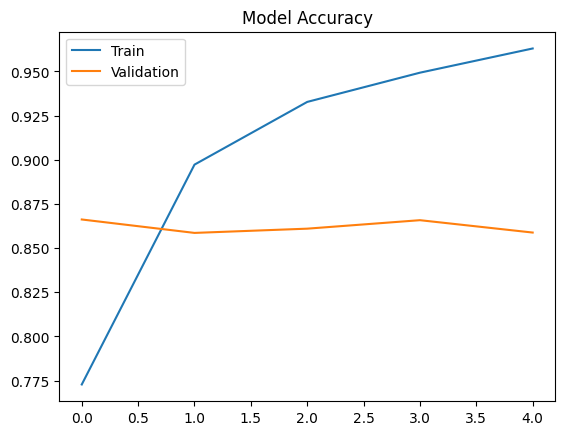

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()